In [5]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [7]:
torch.manual_seed(42)

In [8]:
df = pd.read_csv("/content/market_data.csv")
df.head()

,Price,Close,Close.1,Close.2,Close.3,High,High.1,High.2,High.3,Low,...,Low.2,Low.3,Open,Open.1,Open.2,Open.3,Volume,Volume.1,Volume.2,Volume.3
0,Ticker,^GSPC,^IRX,^TNX,^VIX,^GSPC,^IRX,^TNX,^VIX,^GSPC,...,^TNX,^VIX,^GSPC,^IRX,^TNX,^VIX,^GSPC,^IRX,^TNX,^VIX
1,Date,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2010-01-04,1132.989990234375,0.054999999701976776,3.8410000801086426,20.040000915527344,1133.8699951171875,0.07999999821186066,3.8589999675750732,21.68000030517578,1116.56005859375,...,3.808000087738037,20.030000686645508,1116.56005859375,0.07999999821186066,3.8589999675750732,21.68000030517578,3991400000,0.0,0.0,0
3,2010-01-05,1136.52001953125,0.05999999865889549,3.755000114440918,19.350000381469727,1136.6300048828125,0.06499999761581421,3.799999952316284,20.1299991607666,1129.6600341796875,...,3.749000072479248,19.34000015258789,1132.6600341796875,0.05999999865889549,3.7899999618530273,20.049999237060547,2491020000,0.0,0.0,0
4,2010-01-06,1137.1400146484375,0.04500000178813934,3.808000087738037,19.15999984741211,1139.18994140625,0.05999999865889549,3.8369998931884766,19.68000030517578,1133.949951171875,...,3.760999917984009,18.770000457763672,1135.7099609375,0.05999999865889549,3.7709999084472656,19.59000015258789,4972660000,0.0,0.0,0


In [9]:
df = df.iloc[2:].reset_index(drop=True)
df.head()

,Price,Close,Close.1,Close.2,Close.3,High,High.1,High.2,High.3,Low,...,Low.2,Low.3,Open,Open.1,Open.2,Open.3,Volume,Volume.1,Volume.2,Volume.3
0,2010-01-04,1132.989990234375,0.054999999701976776,3.8410000801086426,20.040000915527344,1133.8699951171875,0.07999999821186066,3.8589999675750732,21.68000030517578,1116.56005859375,...,3.808000087738037,20.030000686645508,1116.56005859375,0.07999999821186066,3.8589999675750732,21.68000030517578,3991400000,0.0,0.0,0
1,2010-01-05,1136.52001953125,0.05999999865889549,3.755000114440918,19.350000381469727,1136.6300048828125,0.06499999761581421,3.799999952316284,20.1299991607666,1129.6600341796875,...,3.749000072479248,19.34000015258789,1132.6600341796875,0.05999999865889549,3.7899999618530273,20.049999237060547,2491020000,0.0,0.0,0
2,2010-01-06,1137.1400146484375,0.04500000178813934,3.808000087738037,19.15999984741211,1139.18994140625,0.05999999865889549,3.8369998931884766,19.68000030517578,1133.949951171875,...,3.760999917984009,18.770000457763672,1135.7099609375,0.05999999865889549,3.7709999084472656,19.59000015258789,4972660000,0.0,0.0,0
3,2010-01-07,1141.68994140625,0.04500000178813934,3.822000026702881,19.059999465942383,1142.4599609375,0.054999999701976776,3.8589999675750732,19.709999084472656,1131.3199462890625,...,3.799999952316284,18.700000762939453,1136.27001953125,0.04500000178813934,3.8450000286102295,19.68000030517578,5270680000,0.0,0.0,0
4,2010-01-08,1144.97998046875,0.03999999910593033,3.808000087738037,18.1299991607666,1145.3900146484375,0.04500000178813934,3.8510000705718994,19.270000457763672,1136.219970703125,...,3.7750000953674316,18.110000610351562,1140.52001953125,0.04500000178813934,3.8429999351501465,19.270000457763672,4389590000,0.0,0.0,0


In [10]:
if 'Price' in df.columns:
    df = df[["Price","Close",'Close.1',"Close.2", "Close.3", "Volume"]]
    df.columns = [
        "Date",
        "SP500",
        "IRX",
        "TNX",
        "VIX",
        "Volume_SP500"
    ]

df["Date"] = pd.to_datetime(df["Date"])
for col in df.columns[1:]:
    df[col] = pd.to_numeric(df[col])
df.head()

,Date,SP500,IRX,TNX,VIX,Volume_SP500
0,2010-01-04,1132.989990,0.055,3.841,20.040001,3991400000
1,2010-01-05,1136.520020,0.060,3.755,19.350000,2491020000
2,2010-01-06,1137.140015,0.045,3.808,19.160000,4972660000
3,2010-01-07,1141.689941,0.045,3.822,19.059999,5270680000
4,2010-01-08,1144.979980,0.040,3.808,18.129999,4389590000


In [11]:
#deriving yield spread
df["Yield_Spread"] = df["TNX"] - df["IRX"]

#deriving returns for s&p 500
df["Returns"] = df['SP500'].pct_change()

#deriving volatality using rollign window of 20 days
df["Volatility"] = df["SP500"].pct_change().rolling(window=20).std()

df.head()

,Date,SP500,IRX,TNX,VIX,Volume_SP500,Yield_Spread,Returns,Volatility
0,2010-01-04,1132.989990,0.055,3.841,20.040001,3991400000,3.786,NaN,NaN
1,2010-01-05,1136.520020,0.060,3.755,19.350000,2491020000,3.695,0.003116,NaN
2,2010-01-06,1137.140015,0.045,3.808,19.160000,4972660000,3.763,0.000546,NaN
3,2010-01-07,1141.689941,0.045,3.822,19.059999,5270680000,3.777,0.004001,NaN
4,2010-01-08,1144.979980,0.040,3.808,18.129999,4389590000,3.768,0.002882,NaN


In [12]:
df = df.dropna()
df.head()

,Date,SP500,IRX,TNX,VIX,Volume_SP500,Yield_Spread,Returns,Volatility
20,2010-02-02,1103.319946,0.090,3.635,21.480000,4749540000,3.545,0.012973,0.010447
21,2010-02-03,1097.280029,0.090,3.703,21.600000,4285450000,3.613,-0.005474,0.010434
22,2010-02-04,1063.109985,0.085,3.610,26.080000,5859690000,3.525,-0.031141,0.012311
23,2010-02-05,1066.189941,0.085,3.546,26.110001,6438900000,3.461,0.002897,0.012279
24,2010-02-08,1056.739990,0.090,3.592,26.510000,4089820000,3.502,-0.008863,0.012246


In [13]:
df.isna().sum()

,0
Date,0
SP500,0
IRX,0
TNX,0
VIX,0
Volume_SP500,0
Yield_Spread,0
Returns,0
Volatility,0


In [14]:
scaler = StandardScaler()
columns_to_scale = ['SP500', 'IRX', 'TNX', 'VIX', 'Volume_SP500','Yield_Spread', 'Returns', 'Volatility']
df[columns_to_scale] = scaler.fit_transform(df[columns_to_scale])
df.head()

,Date,SP500,IRX,TNX,VIX,Volume_SP500,Yield_Spread,Returns,Volatility
20,2010-02-02,-1.243359,-0.712700,1.032735,0.446996,0.746119,1.917074,1.140316,0.194396
21,2010-02-03,-1.247415,-0.712700,1.100497,0.464423,0.278668,1.973182,-0.548838,0.192120
22,2010-02-04,-1.270363,-0.715469,1.007823,1.115056,1.864310,1.900572,-2.899021,0.511072
23,2010-02-05,-1.268294,-0.715469,0.944048,1.119413,2.447716,1.847764,0.217706,0.505640
24,2010-02-08,-1.274640,-0.712700,0.989886,1.177506,0.081620,1.881594,-0.859155,0.500110


In [15]:
Dates = df["Date"]
X = df.iloc[:,4:]
X.head()

,VIX,Volume_SP500,Yield_Spread,Returns,Volatility
20,0.446996,0.746119,1.917074,1.140316,0.194396
21,0.464423,0.278668,1.973182,-0.548838,0.192120
22,1.115056,1.864310,1.900572,-2.899021,0.511072
23,1.119413,2.447716,1.847764,0.217706,0.505640
24,1.177506,0.081620,1.881594,-0.859155,0.500110


In [16]:
X.shape

(4002, 5)

In [17]:
class MarketDataset(Dataset):
  def __init__(self, features):
    self.features = torch.tensor(features.values, dtype=torch.float32)

  def __len__(self):
    return len(self.features)

  def __getitem__(self, index):
    return self.features[index]


In [18]:
dataset = MarketDataset(X)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)


In [19]:
class Autoencoder(nn.Module):
  def __init__(self):
    super().__init__()
    self.encoder = nn.Sequential(
        nn.Linear(5,4),
        nn.ReLU(),
        nn.Linear(4,3),
        nn.ReLU(),
        nn.Linear(3,2)
    )

    self.decoder = nn.Sequential(
      nn.Linear(2,3),
      nn.ReLU(),
      nn.Linear(3,4),
      nn.ReLU(),
      nn.Linear(4,5)
    )

  def forward(self, x):
    encoded = self.encoder(x)
    decoded = self.decoder(encoded)
    return decoded


In [32]:
autoencoder = Autoencoder()
criterion = nn.MSELoss()
optimizer = optim.Adam(autoencoder.parameters(), lr=0.01)

In [33]:
epochs = 100
autoencoder.to(device)
for epoch in range(epochs):
  for batch_features in dataloader:
    batch_features = batch_features.to(device)
    optimizer.zero_grad()
    reconstruction = autoencoder(batch_features)
    loss = criterion(reconstruction, batch_features)
    loss.backward()
    optimizer.step()
  print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item()}")

Epoch 1/100, Loss: 0.25655674934387207
Epoch 2/100, Loss: 0.25455689430236816
Epoch 3/100, Loss: 0.259315550327301
Epoch 4/100, Loss: 0.08420407772064209
Epoch 5/100, Loss: 0.5225269198417664
Epoch 6/100, Loss: 0.16768698394298553
Epoch 7/100, Loss: 0.6180322766304016
Epoch 8/100, Loss: 0.251932293176651
Epoch 9/100, Loss: 0.2870871126651764
Epoch 10/100, Loss: 0.651238739490509
Epoch 11/100, Loss: 0.39066383242607117
Epoch 12/100, Loss: 0.14583955705165863
Epoch 13/100, Loss: 0.07937084883451462
Epoch 14/100, Loss: 0.20164823532104492
Epoch 15/100, Loss: 0.020609978586435318
Epoch 16/100, Loss: 0.10140611976385117
Epoch 17/100, Loss: 0.1267995983362198
Epoch 18/100, Loss: 0.5962089896202087
Epoch 19/100, Loss: 0.06979727745056152
Epoch 20/100, Loss: 0.15928876399993896
Epoch 21/100, Loss: 0.25548768043518066
Epoch 22/100, Loss: 0.060187991708517075
Epoch 23/100, Loss: 0.060973990708589554
Epoch 24/100, Loss: 0.22206370532512665
Epoch 25/100, Loss: 0.32106396555900574
Epoch 26/100, Los

In [22]:
autoencoder.eval()

Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=5, out_features=4, bias=True)
    (1): ReLU()
    (2): Linear(in_features=4, out_features=3, bias=True)
    (3): ReLU()
    (4): Linear(in_features=3, out_features=2, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=2, out_features=3, bias=True)
    (1): ReLU()
    (2): Linear(in_features=3, out_features=4, bias=True)
    (3): ReLU()
    (4): Linear(in_features=4, out_features=5, bias=True)
  )
)

In [23]:
with torch.no_grad():
  latent_space = autoencoder.encoder(dataset.features.to(device))
  print(latent_space.shape)

torch.Size([4002, 2])


In [24]:
latent_space = latent_space.cpu().numpy()
latent_space.shape

(4002, 2)

In [25]:
labels = KMeans(n_clusters=4).fit_predict(latent_space)

In [26]:
labels.shape

(4002,)

In [27]:
labels[:10]

array([2, 2, 1, 1, 2, 2, 2, 2, 2, 2], dtype=int32)

In [28]:
score = silhouette_score(latent_space, labels)
print(score)

0.4165181


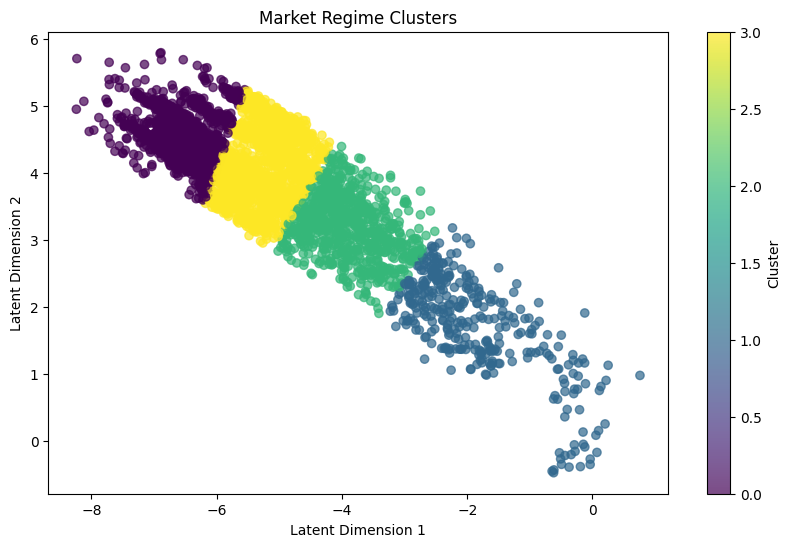

In [29]:
plt.figure(figsize=(10,6))

plt.scatter(
    latent_space[:,0],
    latent_space[:,1],
    c=labels,
    cmap="viridis",
    alpha=0.7
)

plt.xlabel("Latent Dimension 1")
plt.ylabel("Latent Dimension 2")
plt.title("Market Regime Clusters")

plt.colorbar(label="Cluster")

plt.show()

In [36]:
df["Regime"] = labels
df.groupby("Regime").mean()

,Date,SP500,IRX,TNX,VIX,Volume_SP500,Yield_Spread,Returns,Volatility
Regime,,,,,,,,,
0,2016-05-31 19:47:11.016825088,-0.394933,-0.301215,-0.171183,-0.732761,-0.763136,0.307080,0.087095,-0.592902
1,2018-06-01 15:55:47.368421120,-0.052785,-0.243164,-0.348513,2.220176,1.768309,0.073748,-0.388529,2.019337
2,2019-05-28 02:25:27.272727296,0.291503,0.087795,0.015172,0.655308,0.637851,-0.118255,-0.073921,0.498993
3,2018-09-17 13:18:11.272484864,0.217892,0.283404,0.227303,-0.184290,-0.044459,-0.234072,0.048210,-0.183424


# Analysis

Classification of market regime:

1.   0 -> Positive returns and low VIX -> Bullish
2.   1 -> Heavy losses in the returns and high VIX -> Crisis
3.   2 -> Moderate losses in the returns and moderate VIX -> Bearish
4.   3 -> Stable and calm returns and volatility -> Sideways



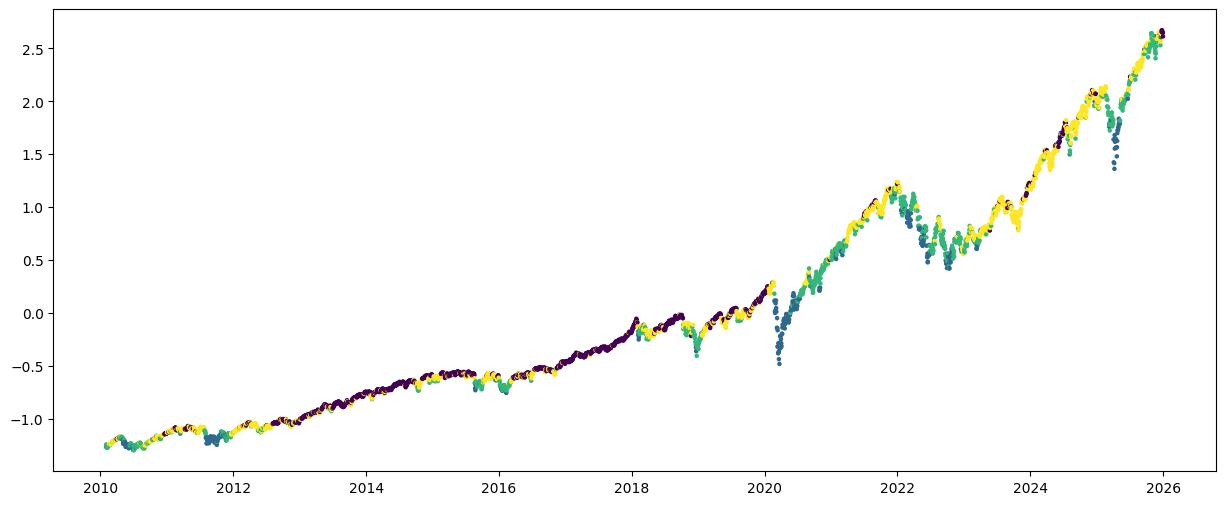

In [37]:
plt.figure(figsize=(15,6))

plt.scatter(
    df["Date"],
    df["SP500"],
    c=df["Regime"],
    cmap="viridis",
    s=5
)

plt.show()

In [43]:
regime_classification = {0:"Bullish", 1:"Crisis", 2:"Bearish", 3:"Sideways", -1:"Unclassified"}
df["Regime"] = labels
df["Regime"] = df["Regime"].fillna(-1).astype(int).map(regime_classification)
df.head()

,Date,SP500,IRX,TNX,VIX,Volume_SP500,Yield_Spread,Returns,Volatility,Regime
20,2010-02-02,-1.243359,-0.712700,1.032735,0.446996,0.746119,1.917074,1.140316,0.194396,Bearish
21,2010-02-03,-1.247415,-0.712700,1.100497,0.464423,0.278668,1.973182,-0.548838,0.192120,Bearish
22,2010-02-04,-1.270363,-0.715469,1.007823,1.115056,1.864310,1.900572,-2.899021,0.511072,Crisis
23,2010-02-05,-1.268294,-0.715469,0.944048,1.119413,2.447716,1.847764,0.217706,0.505640,Crisis
24,2010-02-08,-1.274640,-0.712700,0.989886,1.177506,0.081620,1.881594,-0.859155,0.500110,Bearish
